# Smart Meters in London — limpieza en Go + EDA en Colab

Este notebook separa correctamente **implementación** y **análisis**:

- **Go (biblioteca estándar):** lectura del ZIP, validación, limpieza estructural, deduplicación, agregación diaria, winsorización y generación de variables del modelo.
- **Python/Pandas:** únicamente EDA, auditoría y visualización de los archivos producidos por Go.

La separación es intencional: el entregable exige trabajar con Go para la solución computacional, mientras que el EDA sirve para justificar y verificar las decisiones de preprocesamiento.

## 0. Decisión metodológica: no muestrear 3 millones de filas crudas al azar

El ZIP original contiene del orden de **167 millones de lecturas de media hora**. La unidad de análisis del modelo, sin embargo, es **hogar-día**. Un día completo necesita 48 lecturas de 30 minutos.

Por eso, reducir directamente las filas crudas a 3 millones mediante un muestreo aleatorio sería metodológicamente débil: rompería la continuidad temporal y dejaría muchos días incompletos. La reducción correcta es:

**lecturas crudas → limpieza → deduplicación → agregación hogar-día → días completos → variables temporales**.

El resultado esperado queda alrededor de **3.2–3.3 millones de filas de modelo**. Eso **no es un muestreo**: es una transformación de granularidad. Para el entrenamiento conviene usar todas esas filas. Solo si se necesita estandarizar los benchmarks alrededor de 3,000,000 de observaciones se incluye al final un **muestreo determinista posterior al feature engineering**.

### Por qué el muestreo opcional se hace al final

1. No destruye los 7 días de historia necesarios para `lag_1`, `lag_7` y rolling statistics, porque esas variables ya fueron calculadas.
2. Es reproducible: usa un hash de `household_id + reading_date` y una semilla fija.
3. No usa el valor objetivo para decidir qué fila conservar, por lo que no introduce selección basada en `target`.
4. Conserva aproximadamente las proporciones de train/validation/test al aplicar la misma regla a todas las filas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install ipyfilechooser

from ipyfilechooser import FileChooser
from IPython.display import display

selector = FileChooser('/content/drive/MyDrive')
selector.title = '<b>Selecciona el ZIP Smart Meters in London</b>'
selector.filter_pattern = '*.zip'
display(selector)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.8 MB/s eta 0:00:00


FileChooser(path='/content/drive/MyDrive', filename='', title='<b>Selecciona el ZIP Smart Meters in London</b>…

In [ ]:
from pathlib import Path
import os, shutil, subprocess, sys

ZIP_PATH = selector.selected
if not ZIP_PATH:
    raise ValueError('Selecciona primero el ZIP.')

OUTPUT_DIR = Path('/content/drive/MyDrive/Grupo4_PCD_GO')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Copiamos el ZIP a /content para evitar que Google Drive sea el cuello de botella
# durante la lectura concurrente. Si no hay espacio suficiente, comenta estas 4 líneas
# y usa ZIP_LOCAL = Path(ZIP_PATH).
ZIP_LOCAL = Path('/content') / Path(ZIP_PATH).name
if not ZIP_LOCAL.exists() or ZIP_LOCAL.stat().st_size != Path(ZIP_PATH).stat().st_size:
    print('Copiando ZIP a disco local de Colab...')
    shutil.copy2(ZIP_PATH, ZIP_LOCAL)

GO_WORKERS = min(4, os.cpu_count() or 2)

print('ZIP:', ZIP_LOCAL)
print('Resultados:', OUTPUT_DIR)
print('Workers Go:', GO_WORKERS)

Copiando ZIP a disco local de Colab...
ZIP: /content/Partitioned LCL Data.zip
Resultados: /content/drive/MyDrive/Grupo4_PCD_GO
Workers Go: 2


In [ ]:
# PRE-FLIGHT: inspección rápida del ZIP antes de lanzar el proceso de 167M filas.
# Esto evita descubrir después de varios minutos que el nombre interno o el esquema no coincide.
import zipfile, csv, io

with zipfile.ZipFile(ZIP_LOCAL) as z:
    csv_names = [n for n in z.namelist() if n.lower().endswith('.csv')]
    lcl_names = [n for n in csv_names if 'LCL-June2015v2_' in n]

    print(f'CSV dentro del ZIP: {len(csv_names)}')
    print(f'Fragmentos LCL-June2015v2_* detectados: {len(lcl_names)}')
    print('Primeros archivos:', lcl_names[:5] if lcl_names else csv_names[:10])

    if not lcl_names:
        raise ValueError(
            'El ZIP no contiene archivos LCL-June2015v2_*.csv. '
            'No ejecutes la limpieza todavía: revisa los nombres mostrados arriba.'
        )

    with z.open(lcl_names[0]) as raw:
        txt = io.TextIOWrapper(raw, encoding='utf-8-sig', newline='')
        reader = csv.reader(txt)
        header = next(reader)
        first = next(reader, None)

    print('Encabezado detectado:', header)
    print('Primera fila:', first)

required = {'LCLid', 'stdorToU', 'DateTime', 'KWH/hh (per half hour)'}
normalized = {h.strip().lstrip('\ufeff') for h in header}
missing = required - normalized
if missing:
    raise ValueError(f'Faltan columnas esperadas: {sorted(missing)}')

print('PRE-FLIGHT OK: nombres internos y columnas compatibles con clean_daily.go')


CSV dentro del ZIP: 168
Fragmentos LCL-June2015v2_* detectados: 168
Primeros archivos: ['Small LCL Data/LCL-June2015v2_0.csv', 'Small LCL Data/LCL-June2015v2_1.csv', 'Small LCL Data/LCL-June2015v2_10.csv', 'Small LCL Data/LCL-June2015v2_100.csv', 'Small LCL Data/LCL-June2015v2_101.csv']
Encabezado detectado: ['LCLid', 'stdorToU', 'DateTime', 'KWH/hh (per half hour) ']
Primera fila: ['MAC000002', 'Std', '2012-10-12 00:30:00.0000000', ' 0 ']
PRE-FLIGHT OK: nombres internos y columnas compatibles con clean_daily.go


## 1. Verificar Go

El código de limpieza no usa librerías externas de Go. Solo utiliza la biblioteca estándar (`archive/zip`, `encoding/csv`, `sync`, `time`, `compress/gzip`, etc.).

In [ ]:
import shutil, subprocess

if shutil.which('go') is None:
    !apt-get -qq update
    !apt-get -qq install -y golang-go

!go version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package golang-1.22-src.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../golang-1.22-src_1.22.2-2ubuntu0.4_all.deb ...
Unpacking golang-1.22-src (1.22.2-2ubuntu0.4) ...
Selecting previously unselected package golang-1.22-go.
Preparing to unpack .../golang-1.22-go_1.22.2-2ubuntu0.4_amd64.deb ...
Unpacking golang-1.22-go (1.22.2-2ubuntu0.4) ...
Selecting previously unselected package golang-src.
Preparing to unpack .../golang-src_2%3a1.22~2build1_all.deb ...
Unpacking golang-src (2:1.22~2build1) ...
Selecting previously unselected package golang-go:amd64.
Preparing to unpack .../golang-go_2%3a1.22~2build1_amd64.deb ...
Unpacking golang-go:amd64 (2:1.22~2build1) ...
Setting up golang-1.22-src (1.22.2-2ubuntu0.4) ...
Setting

## 2. Etapa A — limpieza estructural y agregación diaria en Go

Esta etapa recorre **todo el ZIP en streaming**. No intenta cargar los 167 millones de registros en RAM.

Reglas aplicadas:

- valida las columnas del CSV;
- normaliza vacíos/`null`/`nan`;
- valida hogar y tarifa (`Std`/`ToU`);
- convierte fecha y consumo a tipos reales;
- descarta consumos negativos y timestamps fuera de la malla de 00/30 minutos;
- detecta duplicados por `household + day + half-hour slot`;
- marca como conflictivo un día si un duplicado trae valores distintos o cambia la tarifa;
- agrega las 48 lecturas a consumo diario;
- conserva también días incompletos en el archivo diario para que el EDA pueda cuantificar cuánto se pierde;
- usa un **Worker Pool** para procesar fragmentos del ZIP concurrentemente;
- realiza un **k-way merge** al final para unir correctamente un mismo hogar-día aunque haya quedado dividido entre dos archivos del ZIP.

Esta segunda versión **no supone que cada hogar pertenece a un único fragmento**. Los parciales se ordenan por `household_id + fecha` y se fusionan al final sin cargar los ~3.3M hogar-día completos en memoria. Si dos archivos contienen el mismo slot de 30 minutos para el mismo hogar-día, ese día se marca de forma conservadora como conflictivo y queda documentado en la auditoría.


In [ ]:
%%writefile /content/clean_daily.go
package main

import (
	"archive/zip"
	"bufio"
	"container/heap"
	"encoding/csv"
	"flag"
	"fmt"
	"io"
	"math"
	"math/bits"
	"os"
	"path/filepath"
	"runtime"
	"sort"
	"strconv"
	"strings"
	"sync"
	"time"
)

type Stats struct {
	RawRows               int64
	ValidRows             int64
	MissingHousehold      int64
	InvalidTariff         int64
	MissingDateTime       int64
	DateTimeParseErrors   int64
	MissingEnergy         int64
	EnergyParseErrors     int64
	NegativeEnergy        int64
	IrregularTime         int64
	DuplicateRows         int64
	ConflictingDuplicates int64
	ConflictingTariffRows int64
	DaysTotal             int64
	CompleteDays          int64
	IncompleteDays        int64
	ConflictDays          int64
	CrossFileMergeDays    int64
	CrossFileOverlapDays  int64
}

func (s *Stats) Add(o Stats) {
	s.RawRows += o.RawRows
	s.ValidRows += o.ValidRows
	s.MissingHousehold += o.MissingHousehold
	s.InvalidTariff += o.InvalidTariff
	s.MissingDateTime += o.MissingDateTime
	s.DateTimeParseErrors += o.DateTimeParseErrors
	s.MissingEnergy += o.MissingEnergy
	s.EnergyParseErrors += o.EnergyParseErrors
	s.NegativeEnergy += o.NegativeEnergy
	s.IrregularTime += o.IrregularTime
	s.DuplicateRows += o.DuplicateRows
	s.ConflictingDuplicates += o.ConflictingDuplicates
	s.ConflictingTariffRows += o.ConflictingTariffRows
}

type DayAgg struct {
	Household string
	Tariff    string
	Date      string
	Seen      uint64
	Energy    [48]float64
	Conflict  bool
}

type FileResult struct {
	Source   string
	TempPath string
	Stats    Stats
	Err      error
}

func cleanText(s string) string {
	s = strings.TrimSpace(strings.TrimPrefix(s, "\ufeff"))
	switch strings.ToLower(s) {
	case "", "null", "nan", "na", "n/a":
		return ""
	default:
		return s
	}
}

func parseDateTime(s string) (time.Time, error) {
	layouts := []string{
		"2006-01-02 15:04:05.999999999",
		"2006-01-02 15:04:05",
		time.RFC3339Nano,
		time.RFC3339,
	}
	var lastErr error
	for _, layout := range layouts {
		t, err := time.Parse(layout, s)
		if err == nil {
			return t, nil
		}
		lastErr = err
	}
	return time.Time{}, lastErr
}

func headerIndex(header []string) map[string]int {
	m := make(map[string]int, len(header))
	for i, h := range header {
		m[cleanText(h)] = i
	}
	return m
}

func requireColumns(idx map[string]int, names ...string) error {
	for _, name := range names {
		if _, ok := idx[name]; !ok {
			return fmt.Errorf("falta columna requerida %q", name)
		}
	}
	return nil
}

func safeField(row []string, i int) string {
	if i < 0 || i >= len(row) {
		return ""
	}
	return cleanText(row[i])
}

// processEntry limpia un CSV del ZIP y genera agregados parciales por hogar-día.
// Importante: NO presupone que un hogar pertenezca a un único fragmento.
func processEntry(zf *zip.File, tempDir string) FileResult {
	result := FileResult{Source: zf.Name}

	rc, err := zf.Open()
	if err != nil {
		result.Err = err
		return result
	}
	defer rc.Close()

	r := csv.NewReader(bufio.NewReaderSize(rc, 4*1024*1024))
	r.FieldsPerRecord = -1
	r.ReuseRecord = true

	header, err := r.Read()
	if err != nil {
		result.Err = fmt.Errorf("%s: no se pudo leer encabezado: %w", zf.Name, err)
		return result
	}
	idx := headerIndex(header)
	if err := requireColumns(idx, "LCLid", "stdorToU", "DateTime", "KWH/hh (per half hour)"); err != nil {
		result.Err = fmt.Errorf("%s: %w; encabezado=%v", zf.Name, err, header)
		return result
	}

	days := make(map[string]*DayAgg, 30000)

	for {
		row, err := r.Read()
		if err == io.EOF {
			break
		}
		if err != nil {
			result.Err = fmt.Errorf("%s: error CSV: %w", zf.Name, err)
			return result
		}
		result.Stats.RawRows++

		household := safeField(row, idx["LCLid"])
		if household == "" {
			result.Stats.MissingHousehold++
			continue
		}

		tariff := safeField(row, idx["stdorToU"])
		if tariff != "Std" && tariff != "ToU" {
			result.Stats.InvalidTariff++
			continue
		}

		dtText := safeField(row, idx["DateTime"])
		if dtText == "" {
			result.Stats.MissingDateTime++
			continue
		}
		dt, err := parseDateTime(dtText)
		if err != nil {
			result.Stats.DateTimeParseErrors++
			continue
		}
		if (dt.Minute() != 0 && dt.Minute() != 30) || dt.Second() != 0 {
			result.Stats.IrregularTime++
			continue
		}

		energyText := safeField(row, idx["KWH/hh (per half hour)"])
		if energyText == "" {
			result.Stats.MissingEnergy++
			continue
		}
		energy, err := strconv.ParseFloat(energyText, 64)
		if err != nil || math.IsNaN(energy) || math.IsInf(energy, 0) {
			result.Stats.EnergyParseErrors++
			continue
		}
		if energy < 0 {
			result.Stats.NegativeEnergy++
			continue
		}

		result.Stats.ValidRows++
		date := dt.Format("2006-01-02")
		key := household + "\x1f" + date
		agg := days[key]
		if agg == nil {
			agg = &DayAgg{Household: household, Tariff: tariff, Date: date}
			days[key] = agg
		}
		if agg.Tariff != tariff {
			agg.Conflict = true
			result.Stats.ConflictingTariffRows++
		}

		slot := dt.Hour()*2 + dt.Minute()/30
		bit := uint64(1) << uint(slot)
		if agg.Seen&bit != 0 {
			result.Stats.DuplicateRows++
			if math.Abs(agg.Energy[slot]-energy) > 1e-12 {
				agg.Conflict = true
				result.Stats.ConflictingDuplicates++
			}
			continue
		}
		agg.Seen |= bit
		agg.Energy[slot] = energy
	}

	base := filepath.Base(zf.Name)
	tmp, err := os.CreateTemp(tempDir, strings.TrimSuffix(base, ".csv")+"_*.part.csv")
	if err != nil {
		result.Err = err
		return result
	}
	result.TempPath = tmp.Name()
	bw := bufio.NewWriterSize(tmp, 2*1024*1024)
	w := csv.NewWriter(bw)

	keys := make([]string, 0, len(days))
	for k := range days {
		keys = append(keys, k)
	}
	sort.Strings(keys)

	for _, k := range keys {
		agg := days[k]
		var sum float64
		zero := 0
		for i := 0; i < 48; i++ {
			bit := uint64(1) << uint(i)
			if agg.Seen&bit == 0 {
				continue
			}
			sum += agg.Energy[i]
			if agg.Energy[i] == 0 {
				zero++
			}
		}
		record := []string{
			agg.Household,
			agg.Tariff,
			agg.Date,
			strconv.FormatUint(agg.Seen, 16),
			strconv.FormatFloat(sum, 'g', -1, 64),
			strconv.Itoa(zero),
			strconv.FormatBool(agg.Conflict),
			zf.Name,
		}
		if err := w.Write(record); err != nil {
			result.Err = err
			break
		}
	}
	w.Flush()
	if err := w.Error(); err != nil && result.Err == nil {
		result.Err = err
	}
	if err := bw.Flush(); err != nil && result.Err == nil {
		result.Err = err
	}
	if err := tmp.Close(); err != nil && result.Err == nil {
		result.Err = err
	}
	return result
}

type PartRow struct {
	Household string
	Tariff    string
	Date      string
	Seen      uint64
	Sum       float64
	Zero      int
	Conflict  bool
	Source    string
}

func (p PartRow) Key() string { return p.Household + "\x1f" + p.Date }

func parsePartRow(rec []string) (PartRow, error) {
	if len(rec) < 8 {
		return PartRow{}, fmt.Errorf("registro parcial con %d columnas", len(rec))
	}
	mask, err := strconv.ParseUint(rec[3], 16, 64)
	if err != nil {
		return PartRow{}, err
	}
	sum, err := strconv.ParseFloat(rec[4], 64)
	if err != nil {
		return PartRow{}, err
	}
	zero, err := strconv.Atoi(rec[5])
	if err != nil {
		return PartRow{}, err
	}
	conflict, err := strconv.ParseBool(rec[6])
	if err != nil {
		return PartRow{}, err
	}
	return PartRow{rec[0], rec[1], rec[2], mask, sum, zero, conflict, rec[7]}, nil
}

type partCursor struct {
	idx    int
	file   *os.File
	reader *csv.Reader
	row    PartRow
}

type cursorHeap []*partCursor

func (h cursorHeap) Len() int { return len(h) }
func (h cursorHeap) Less(i, j int) bool {
	if h[i].row.Key() == h[j].row.Key() {
		return h[i].idx < h[j].idx
	}
	return h[i].row.Key() < h[j].row.Key()
}
func (h cursorHeap) Swap(i, j int) { h[i], h[j] = h[j], h[i] }
func (h *cursorHeap) Push(x any)   { *h = append(*h, x.(*partCursor)) }
func (h *cursorHeap) Pop() any {
	old := *h
	n := len(old)
	x := old[n-1]
	*h = old[:n-1]
	return x
}

func advanceCursor(c *partCursor) (bool, error) {
	rec, err := c.reader.Read()
	if err == io.EOF {
		return false, nil
	}
	if err != nil {
		return false, err
	}
	row, err := parsePartRow(rec)
	if err != nil {
		return false, err
	}
	c.row = row
	return true, nil
}

// mergeParts hace un k-way merge de los archivos parciales ya ordenados.
// Así se pueden unir días partidos entre CSVs sin cargar millones de días en RAM.
func mergeParts(parts []FileResult, outPath string, stats *Stats) (int, error) {
	if dir := filepath.Dir(outPath); dir != "." {
		if err := os.MkdirAll(dir, 0o755); err != nil {
			return 0, err
		}
	}
	out, err := os.Create(outPath)
	if err != nil {
		return 0, err
	}
	defer out.Close()
	bw := bufio.NewWriterSize(out, 4*1024*1024)
	cw := csv.NewWriter(bw)
	if err := cw.Write([]string{"household_id", "tariff", "reading_date", "readings_count", "daily_energy_kwh", "zero_readings", "has_conflict", "source_file"}); err != nil {
		return 0, err
	}

	h := &cursorHeap{}
	heap.Init(h)
	cursors := make([]*partCursor, 0, len(parts))
	for i, p := range parts {
		f, err := os.Open(p.TempPath)
		if err != nil {
			return 0, err
		}
		c := &partCursor{idx: i, file: f, reader: csv.NewReader(bufio.NewReaderSize(f, 1*1024*1024))}
		c.reader.FieldsPerRecord = -1
		ok, err := advanceCursor(c)
		if err != nil {
			f.Close()
			return 0, err
		}
		if ok {
			heap.Push(h, c)
			cursors = append(cursors, c)
		} else {
			f.Close()
		}
	}
	defer func() {
		for _, c := range cursors {
			_ = c.file.Close()
		}
	}()

	uniqueHouseholds := 0
	lastHousehold := ""

	for h.Len() > 0 {
		c := heap.Pop(h).(*partCursor)
		agg := c.row
		key := agg.Key()
		sources := []string{agg.Source}
		sourceSet := map[string]struct{}{agg.Source: {}}
		mergedFiles := 1

		ok, err := advanceCursor(c)
		if err != nil {
			return 0, err
		}
		if ok {
			heap.Push(h, c)
		}

		// Consumir todas las filas parciales con la misma clave hogar-fecha.
		for h.Len() > 0 && (*h)[0].row.Key() == key {
			c2 := heap.Pop(h).(*partCursor)
			r2 := c2.row
			mergedFiles++
			if _, exists := sourceSet[r2.Source]; !exists {
				sourceSet[r2.Source] = struct{}{}
				sources = append(sources, r2.Source)
			}
			if agg.Tariff != r2.Tariff {
				agg.Conflict = true
				stats.ConflictingTariffRows++
			}
			overlap := agg.Seen & r2.Seen
			if overlap != 0 {
				// No tenemos los 48 valores individuales en el archivo parcial;
				// por seguridad, un solapamiento entre fragmentos se marca conflictivo.
				agg.Conflict = true
				stats.CrossFileOverlapDays++
			}
			agg.Seen |= r2.Seen
			agg.Sum += r2.Sum
			agg.Zero += r2.Zero
			agg.Conflict = agg.Conflict || r2.Conflict

			ok, err := advanceCursor(c2)
			if err != nil {
				return 0, err
			}
			if ok {
				heap.Push(h, c2)
			}
		}

		if mergedFiles > 1 {
			stats.CrossFileMergeDays++
		}
		sort.Strings(sources)
		count := bits.OnesCount64(agg.Seen)
		stats.DaysTotal++
		if agg.Conflict {
			stats.ConflictDays++
		}
		if count == 48 && !agg.Conflict {
			stats.CompleteDays++
		} else {
			stats.IncompleteDays++
		}

		if agg.Household != lastHousehold {
			uniqueHouseholds++
			lastHousehold = agg.Household
		}

		rec := []string{
			agg.Household,
			agg.Tariff,
			agg.Date,
			strconv.Itoa(count),
			strconv.FormatFloat(agg.Sum, 'g', -1, 64),
			strconv.Itoa(agg.Zero),
			strconv.FormatBool(agg.Conflict),
			strings.Join(sources, ";"),
		}
		if err := cw.Write(rec); err != nil {
			return 0, err
		}
	}

	cw.Flush()
	if err := cw.Error(); err != nil {
		return 0, err
	}
	if err := bw.Flush(); err != nil {
		return 0, err
	}
	return uniqueHouseholds, nil
}

func writeAudit(path string, stats Stats, sourceFiles, households int) error {
	if dir := filepath.Dir(path); dir != "." {
		if err := os.MkdirAll(dir, 0o755); err != nil {
			return err
		}
	}
	f, err := os.Create(path)
	if err != nil {
		return err
	}
	defer f.Close()
	w := csv.NewWriter(f)
	defer w.Flush()
	_ = w.Write([]string{"metric", "value"})
	metrics := []struct {
		name  string
		value int64
	}{
		{"source_csv_files", int64(sourceFiles)},
		{"unique_households", int64(households)},
		{"raw_rows", stats.RawRows},
		{"valid_rows", stats.ValidRows},
		{"missing_household", stats.MissingHousehold},
		{"invalid_tariff", stats.InvalidTariff},
		{"missing_datetime", stats.MissingDateTime},
		{"datetime_parse_errors", stats.DateTimeParseErrors},
		{"missing_energy", stats.MissingEnergy},
		{"energy_parse_errors", stats.EnergyParseErrors},
		{"negative_energy", stats.NegativeEnergy},
		{"irregular_time", stats.IrregularTime},
		{"duplicate_rows", stats.DuplicateRows},
		{"conflicting_duplicates", stats.ConflictingDuplicates},
		{"conflicting_tariff_rows", stats.ConflictingTariffRows},
		{"household_days", stats.DaysTotal},
		{"complete_household_days", stats.CompleteDays},
		{"incomplete_or_conflict_days", stats.IncompleteDays},
		{"conflict_days", stats.ConflictDays},
		{"cross_file_merge_days", stats.CrossFileMergeDays},
		{"cross_file_overlap_days", stats.CrossFileOverlapDays},
	}
	for _, m := range metrics {
		if err := w.Write([]string{m.name, strconv.FormatInt(m.value, 10)}); err != nil {
			return err
		}
	}
	return w.Error()
}

func main() {
	zipPath := flag.String("zip", "", "ruta al ZIP Smart Meters in London")
	outPath := flag.String("out", "lcl_diario_go.csv", "CSV diario de salida")
	auditPath := flag.String("audit", "audit_cleaning_go.csv", "CSV de auditoría")
	workers := flag.Int("workers", min(4, runtime.NumCPU()), "número de workers concurrentes")
	flag.Parse()

	if *zipPath == "" {
		fmt.Fprintln(os.Stderr, "ERROR: usa -zip /ruta/dataset.zip")
		os.Exit(2)
	}
	if *workers < 1 {
		*workers = 1
	}

	zr, err := zip.OpenReader(*zipPath)
	if err != nil {
		fmt.Fprintln(os.Stderr, "ERROR abriendo ZIP:", err)
		os.Exit(1)
	}
	defer zr.Close()

	entries := make([]*zip.File, 0, 200)
	for _, zf := range zr.File {
		name := strings.ToLower(zf.Name)
		if strings.Contains(zf.Name, "LCL-June2015v2_") && strings.HasSuffix(name, ".csv") {
			entries = append(entries, zf)
		}
	}
	sort.Slice(entries, func(i, j int) bool { return entries[i].Name < entries[j].Name })
	if len(entries) == 0 {
		fmt.Fprintln(os.Stderr, "ERROR: no se encontraron fragmentos LCL-June2015v2_*.csv dentro del ZIP")
		fmt.Fprintln(os.Stderr, "Sugerencia: inspecciona los nombres con Python zipfile antes de ejecutar la limpieza.")
		os.Exit(1)
	}

	fmt.Printf("Fragmentos detectados: %d | workers: %d\n", len(entries), min(*workers, len(entries)))

	tempDir, err := os.MkdirTemp("", "lcl_go_parts_*")
	if err != nil {
		fmt.Fprintln(os.Stderr, "ERROR creando temporales:", err)
		os.Exit(1)
	}
	defer os.RemoveAll(tempDir)

	jobs := make(chan *zip.File)
	results := make(chan FileResult, len(entries))
	var wg sync.WaitGroup
	for i := 0; i < min(*workers, len(entries)); i++ {
		wg.Add(1)
		go func() {
			defer wg.Done()
			for zf := range jobs {
				results <- processEntry(zf, tempDir)
			}
		}()
	}
	go func() {
		for _, zf := range entries {
			jobs <- zf
		}
		close(jobs)
		wg.Wait()
		close(results)
	}()

	all := make([]FileResult, 0, len(entries))
	var total Stats
	done := 0
	for res := range results {
		if res.Err != nil {
			fmt.Fprintf(os.Stderr, "ERROR en %s: %v\n", res.Source, res.Err)
			os.Exit(1)
		}
		done++
		all = append(all, res)
		total.Add(res.Stats)
		fmt.Printf("OK %3d/%d %-32s raw=%d\n", done, len(entries), filepath.Base(res.Source), res.Stats.RawRows)
	}

	sort.Slice(all, func(i, j int) bool { return all[i].Source < all[j].Source })
	fmt.Println("Uniendo agregados hogar-día entre fragmentos...")
	households, err := mergeParts(all, *outPath, &total)
	if err != nil {
		fmt.Fprintln(os.Stderr, "ERROR durante merge final:", err)
		os.Exit(1)
	}

	if err := writeAudit(*auditPath, total, len(entries), households); err != nil {
		fmt.Fprintln(os.Stderr, "ERROR escribiendo auditoría:", err)
		os.Exit(1)
	}

	fmt.Println("\n=== RESUMEN ===")
	fmt.Printf("CSV fuente: %d\n", len(entries))
	fmt.Printf("Hogares únicos: %d\n", households)
	fmt.Printf("Filas crudas leídas: %d\n", total.RawRows)
	fmt.Printf("Filas válidas: %d\n", total.ValidRows)
	fmt.Printf("Hogar-día generados: %d\n", total.DaysTotal)
	fmt.Printf("Hogar-día completos: %d\n", total.CompleteDays)
	fmt.Printf("Días unidos desde >1 fragmento: %d\n", total.CrossFileMergeDays)
	fmt.Printf("Días con solapamiento entre fragmentos: %d\n", total.CrossFileOverlapDays)
	fmt.Printf("Salida: %s\nAuditoría: %s\n", *outPath, *auditPath)
}


Writing /content/clean_daily.go


In [ ]:
!gofmt -w /content/clean_daily.go
!go build -o /content/clean_daily /content/clean_daily.go
print('clean_daily.go compiló correctamente.')

clean_daily.go compiló correctamente.


In [ ]:
# Ejecutamos sobre el disco local de Colab: escribir millones de filas directamente
# en Google Drive puede convertirse en un cuello de botella de E/S.
DAILY_LOCAL = Path('/content/lcl_diario_go.csv')
AUDIT_LOCAL = Path('/content/audit_cleaning_go.csv')

DAILY_CSV = OUTPUT_DIR / 'lcl_diario_go.csv'
AUDIT_CLEAN = OUTPUT_DIR / 'audit_cleaning_go.csv'

cmd = [
    '/content/clean_daily',
    '-zip', str(ZIP_LOCAL),
    '-out', str(DAILY_LOCAL),
    '-audit', str(AUDIT_LOCAL),
    '-workers', str(GO_WORKERS),
]
print('Ejecutando:', ' '.join(cmd))
print('La salida se mostrará en vivo para que un error de Go no quede oculto detrás de CalledProcessError.\n')

proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in proc.stdout:
    print(line, end='')
return_code = proc.wait()

if return_code != 0:
    raise RuntimeError(
        f'clean_daily terminó con código {return_code}. '
        'El mensaje inmediatamente anterior es la causa real; no continúes con model_prep.'
    )

# Solo después de terminar correctamente copiamos los resultados a Drive.
shutil.copy2(DAILY_LOCAL, DAILY_CSV)
shutil.copy2(AUDIT_LOCAL, AUDIT_CLEAN)
print('\nCopiado a Drive:')
print(' -', DAILY_CSV)
print(' -', AUDIT_CLEAN)


Ejecutando: /content/clean_daily -zip /content/Partitioned LCL Data.zip -out /content/lcl_diario_go.csv -audit /content/audit_cleaning_go.csv -workers 2
La salida se mostrará en vivo para que un error de Go no quede oculto detrás de CalledProcessError.

Fragmentos detectados: 168 | workers: 2
OK   1/168 LCL-June2015v2_1.csv             raw=1000000
OK   2/168 LCL-June2015v2_0.csv             raw=1000000
OK   3/168 LCL-June2015v2_10.csv            raw=1000000
OK   4/168 LCL-June2015v2_100.csv           raw=1000000
OK   5/168 LCL-June2015v2_101.csv           raw=1000000
OK   6/168 LCL-June2015v2_102.csv           raw=1000000
OK   7/168 LCL-June2015v2_103.csv           raw=1000000
OK   8/168 LCL-June2015v2_104.csv           raw=1000000
OK   9/168 LCL-June2015v2_105.csv           raw=1000000
OK  10/168 LCL-June2015v2_106.csv           raw=1000000
OK  11/168 LCL-June2015v2_107.csv           raw=1000000
OK  12/168 LCL-June2015v2_108.csv           raw=1000000
OK  13/168 LCL-June2015v2_109.csv 

## 3. EDA de validación sobre la salida de Go

El EDA **no reemplaza la limpieza**: verifica lo que produjo Go y genera tablas/gráficos para el informe. Esto permite documentar cuántos registros fueron válidos, cuántos días quedaron incompletos y cuál es la distribución del consumo diario.

,metric,value
0,source_csv_files,168
1,unique_households,5561
2,raw_rows,167932474
3,valid_rows,167926914
4,missing_household,0
5,invalid_tariff,0
6,missing_datetime,0
7,datetime_parse_errors,0
8,missing_energy,0
9,energy_parse_errors,0


,métrica,valor
0,hogar-día,3.510403e+06
1,días completos y sin conflicto,3.469352e+06
2,días con conflicto,0.000000e+00
3,media kWh/día,1.012414e+01
4,mínimo kWh/día,0.000000e+00
5,máximo kWh/día,3.325560e+02


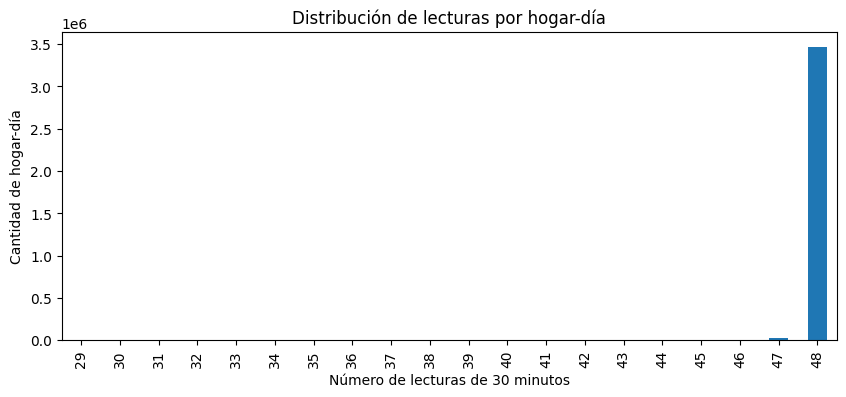

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

clean_audit = pd.read_csv(AUDIT_CLEAN)
display(clean_audit)

# Leemos el CSV diario por chunks para no depender de que todo quepa en memoria.
counts = {}
rows = 0
complete_days = 0
conflict_days = 0
sum_kwh = 0.0
min_kwh = float('inf')
max_kwh = float('-inf')

for chunk in pd.read_csv(DAILY_CSV, chunksize=250_000):
    rows += len(chunk)
    vc = chunk['readings_count'].value_counts()
    for k, v in vc.items():
        counts[int(k)] = counts.get(int(k), 0) + int(v)
    complete_days += int(((chunk['readings_count'] == 48) & (~chunk['has_conflict'])).sum())
    conflict_days += int(chunk['has_conflict'].sum())
    s = chunk['daily_energy_kwh']
    sum_kwh += float(s.sum())
    min_kwh = min(min_kwh, float(s.min()))
    max_kwh = max(max_kwh, float(s.max()))

eda_daily = pd.DataFrame({
    'métrica': ['hogar-día', 'días completos y sin conflicto', 'días con conflicto', 'media kWh/día', 'mínimo kWh/día', 'máximo kWh/día'],
    'valor': [rows, complete_days, conflict_days, sum_kwh/rows, min_kwh, max_kwh]
})
display(eda_daily)

freq = pd.Series(counts).sort_index()
ax = freq.tail(20).plot(kind='bar', figsize=(10,4), title='Distribución de lecturas por hogar-día')
ax.set_xlabel('Número de lecturas de 30 minutos')
ax.set_ylabel('Cantidad de hogar-día')
plt.show()

## 4. Etapa B — winsorización y feature engineering en Go

Se replica la lógica que veníamos usando en el notebook anterior, pero ahora la transformación definitiva queda en Go:

- solo días completos (`readings_count = 48`);
- separación temporal: `train < 2013-10-01`, `validation < 2014-01-01`, resto `test`;
- los límites de outliers se calculan **solo con TRAIN** para evitar data leakage;
- límite por hogar = `Q3 + 3×IQR` cuando el hogar tiene al menos 30 días de train;
- si el límite por hogar es muy bajo o no existe, se usa como piso el límite global de TRAIN;
- después de winsorizar se calculan `lag_1`, `lag_7`, media móvil 7 y desviación estándar móvil 7;
- solo se emiten filas con 7 días consecutivos de historia;
- se conserva `target_daily_kwh_raw` además del target ajustado para auditar el efecto de la winsorización.

In [ ]:
%%writefile /content/model_prep.go
package main

import (
	"bufio"
	"compress/gzip"
	"encoding/csv"
	"flag"
	"fmt"
	"io"
	"math"
	"os"
	"path/filepath"
	"sort"
	"strconv"
	"strings"
	"time"
)

type DailyRow struct {
	Date   time.Time
	Tariff string
	Raw    float64
}

type CapInfo struct {
	TrainDays int
	Q1        float64
	Q3        float64
	Cap       float64
	Rule      string
}

type SplitStats struct {
	Rows       int64
	CappedRows int64
	SumRaw     float64
	SumCapped  float64
	MaxRaw     float64
	MaxCapped  float64
}

func openCSVReader(path string) (io.ReadCloser, *csv.Reader, error) {
	f, err := os.Open(path)
	if err != nil {
		return nil, nil, err
	}
	var rc io.ReadCloser = f
	var reader io.Reader = bufio.NewReaderSize(f, 4*1024*1024)
	if strings.HasSuffix(strings.ToLower(path), ".gz") {
		gz, err := gzip.NewReader(reader)
		if err != nil {
			f.Close()
			return nil, nil, err
		}
		rc = &multiCloser{Reader: gz, closers: []io.Closer{gz, f}}
		reader = gz
	}
	r := csv.NewReader(bufio.NewReaderSize(reader, 4*1024*1024))
	r.FieldsPerRecord = -1
	r.ReuseRecord = true
	return rc, r, nil
}

type multiCloser struct {
	io.Reader
	closers []io.Closer
}

func (m *multiCloser) Close() error {
	var first error
	for _, c := range m.closers {
		if err := c.Close(); err != nil && first == nil {
			first = err
		}
	}
	return first
}

func createCSVWriter(path string) (io.WriteCloser, *csv.Writer, error) {
	if dir := filepath.Dir(path); dir != "." {
		if err := os.MkdirAll(dir, 0o755); err != nil {
			return nil, nil, err
		}
	}
	f, err := os.Create(path)
	if err != nil {
		return nil, nil, err
	}
	var wc io.WriteCloser = f
	var writer io.Writer = f
	if strings.HasSuffix(strings.ToLower(path), ".gz") {
		gz := gzip.NewWriter(f)
		wc = &writerCloser{gzipWriter: gz, file: f}
		writer = gz
	}
	w := csv.NewWriter(writer)
	return wc, w, nil
}

type writerCloser struct {
	gzipWriter *gzip.Writer
	file       *os.File
}

func (w *writerCloser) Write(p []byte) (int, error) { return w.gzipWriter.Write(p) }
func (w *writerCloser) Close() error {
	if err := w.gzipWriter.Close(); err != nil {
		w.file.Close()
		return err
	}
	return w.file.Close()
}

func indexHeader(header []string) map[string]int {
	m := make(map[string]int, len(header))
	for i, h := range header {
		m[strings.TrimSpace(strings.TrimPrefix(h, "\ufeff"))] = i
	}
	return m
}

func field(row []string, idx map[string]int, name string) string {
	i, ok := idx[name]
	if !ok || i < 0 || i >= len(row) {
		return ""
	}
	return strings.TrimSpace(row[i])
}

func quantileCont(sortedVals []float64, q float64) float64 {
	if len(sortedVals) == 0 {
		return math.NaN()
	}
	if len(sortedVals) == 1 {
		return sortedVals[0]
	}
	pos := q * float64(len(sortedVals)-1)
	lo := int(math.Floor(pos))
	hi := int(math.Ceil(pos))
	if lo == hi {
		return sortedVals[lo]
	}
	frac := pos - float64(lo)
	return sortedVals[lo]*(1-frac) + sortedVals[hi]*frac
}

func splitForDate(d time.Time) string {
	trainEnd := time.Date(2013, 10, 1, 0, 0, 0, 0, time.UTC)
	validationEnd := time.Date(2014, 1, 1, 0, 0, 0, 0, time.UTC)
	if d.Before(trainEnd) {
		return "train"
	}
	if d.Before(validationEnd) {
		return "validation"
	}
	return "test"
}

func capped(x, cap float64) float64 {
	if x < 0 {
		return 0
	}
	if x > cap {
		return cap
	}
	return x
}

func meanStdSample(xs []float64) (float64, float64) {
	if len(xs) == 0 {
		return math.NaN(), math.NaN()
	}
	var sum float64
	for _, x := range xs {
		sum += x
	}
	mean := sum / float64(len(xs))
	if len(xs) == 1 {
		return mean, math.NaN()
	}
	var ss float64
	for _, x := range xs {
		d := x - mean
		ss += d * d
	}
	return mean, math.Sqrt(ss / float64(len(xs)-1))
}

func main() {
	inPath := flag.String("in", "lcl_diario_go.csv", "CSV diario generado por clean_daily.go")
	outPath := flag.String("out", "lcl_modelo_go.csv.gz", "dataset de modelo (.csv o .csv.gz)")
	auditPath := flag.String("audit", "audit_model_prep_go.csv", "auditoría de salida")
	flag.Parse()

	rc, r, err := openCSVReader(*inPath)
	if err != nil {
		panic(err)
	}
	defer rc.Close()

	header, err := r.Read()
	if err != nil {
		panic(err)
	}
	idx := indexHeader(header)
	required := []string{"household_id", "tariff", "reading_date", "readings_count", "daily_energy_kwh", "has_conflict"}
	for _, c := range required {
		if _, ok := idx[c]; !ok {
			panic("falta columna requerida: " + c)
		}
	}

	byHousehold := make(map[string][]DailyRow, 6000)
	var inputRows, completeRows int64
	for {
		row, err := r.Read()
		if err == io.EOF {
			break
		}
		if err != nil {
			panic(err)
		}
		inputRows++
		if field(row, idx, "has_conflict") == "true" {
			continue
		}
		count, err := strconv.Atoi(field(row, idx, "readings_count"))
		if err != nil || count != 48 {
			continue
		}
		household := field(row, idx, "household_id")
		tariff := field(row, idx, "tariff")
		if household == "" || (tariff != "Std" && tariff != "ToU") {
			continue
		}
		date, err := time.Parse("2006-01-02", field(row, idx, "reading_date"))
		if err != nil {
			continue
		}
		raw, err := strconv.ParseFloat(field(row, idx, "daily_energy_kwh"), 64)
		if err != nil || raw < 0 || math.IsNaN(raw) || math.IsInf(raw, 0) {
			continue
		}
		byHousehold[household] = append(byHousehold[household], DailyRow{Date: date, Tariff: tariff, Raw: raw})
		completeRows++
	}

	// Orden temporal por hogar y construcción del conjunto TRAIN.
	globalTrain := make([]float64, 0, completeRows*2/3)
	for h := range byHousehold {
		rows := byHousehold[h]
		sort.Slice(rows, func(i, j int) bool { return rows[i].Date.Before(rows[j].Date) })
		byHousehold[h] = rows
		for _, row := range rows {
			if splitForDate(row.Date) == "train" {
				globalTrain = append(globalTrain, row.Raw)
			}
		}
	}
	if len(globalTrain) == 0 {
		panic("no hay datos de entrenamiento")
	}
	sort.Float64s(globalTrain)
	q1g := quantileCont(globalTrain, 0.25)
	q3g := quantileCont(globalTrain, 0.75)
	globalCap := q3g + 3.0*(q3g-q1g)

	caps := make(map[string]CapInfo, len(byHousehold))
	for h, rows := range byHousehold {
		trainVals := make([]float64, 0, len(rows))
		for _, row := range rows {
			if splitForDate(row.Date) == "train" {
				trainVals = append(trainVals, row.Raw)
			}
		}
		sort.Float64s(trainVals)
		info := CapInfo{TrainDays: len(trainVals), Q1: math.NaN(), Q3: math.NaN(), Cap: globalCap, Rule: "global_fallback"}
		if len(trainVals) > 0 {
			info.Q1 = quantileCont(trainVals, 0.25)
			info.Q3 = quantileCont(trainVals, 0.75)
		}
		if len(trainVals) >= 30 && info.Q3 > info.Q1 {
			householdCap := info.Q3 + 3.0*(info.Q3-info.Q1)
			if householdCap < globalCap {
				info.Cap = globalCap
				info.Rule = "global_floor"
			} else {
				info.Cap = householdCap
				info.Rule = "household_cap"
			}
		}
		caps[h] = info
	}

	wc, w, err := createCSVWriter(*outPath)
	if err != nil {
		panic(err)
	}
	defer wc.Close()

	outHeader := []string{
		"household_id", "reading_date", "tariff_tou", "is_weekend",
		"dow_sin", "dow_cos", "month_sin", "month_cos", "day_index",
		"lag_1_kwh", "lag_7_kwh", "rolling_mean_7_kwh", "rolling_std_7_kwh",
		"final_upper_cap", "target_was_capped", "dataset_split",
		"target_daily_kwh_raw", "target_daily_kwh_capped",
	}
	if err := w.Write(outHeader); err != nil {
		panic(err)
	}

	origin := time.Date(2011, 1, 1, 0, 0, 0, 0, time.UTC)
	stats := map[string]*SplitStats{"train": {}, "validation": {}, "test": {}}
	var modelRows int64

	houses := make([]string, 0, len(byHousehold))
	for h := range byHousehold {
		houses = append(houses, h)
	}
	sort.Strings(houses)

	for _, h := range houses {
		rows := byHousehold[h]
		capValue := caps[h].Cap
		cappedValues := make([]float64, len(rows))
		for i, row := range rows {
			cappedValues[i] = capped(row.Raw, capValue)
		}
		for i := 7; i < len(rows); i++ {
			// Equivalente a las condiciones del notebook previo:
			// debe existir el día anterior y el séptimo día anterior.
			if int(rows[i].Date.Sub(rows[i-1].Date).Hours()/24) != 1 {
				continue
			}
			if int(rows[i].Date.Sub(rows[i-7].Date).Hours()/24) != 7 {
				continue
			}
			prev7 := cappedValues[i-7 : i]
			rollMean, rollStd := meanStdSample(prev7)
			if math.IsNaN(rollStd) {
				continue
			}

			row := rows[i]
			dow := float64(row.Date.Weekday()) // Sunday=0 ... Saturday=6, igual que DuckDB DOW.
			month0 := float64(int(row.Date.Month()) - 1)
			weekend := 0
			if row.Date.Weekday() == time.Saturday || row.Date.Weekday() == time.Sunday {
				weekend = 1
			}
			tariffTOU := 0
			if row.Tariff == "ToU" {
				tariffTOU = 1
			}
			dayIndex := int(row.Date.Sub(origin).Hours() / 24)
			split := splitForDate(row.Date)
			wasCapped := 0
			if row.Raw > capValue {
				wasCapped = 1
			}
			targetCapped := cappedValues[i]

			record := []string{
				h,
				row.Date.Format("2006-01-02"),
				strconv.Itoa(tariffTOU),
				strconv.Itoa(weekend),
				strconv.FormatFloat(math.Sin(2*math.Pi*dow/7.0), 'g', -1, 64),
				strconv.FormatFloat(math.Cos(2*math.Pi*dow/7.0), 'g', -1, 64),
				strconv.FormatFloat(math.Sin(2*math.Pi*month0/12.0), 'g', -1, 64),
				strconv.FormatFloat(math.Cos(2*math.Pi*month0/12.0), 'g', -1, 64),
				strconv.Itoa(dayIndex),
				strconv.FormatFloat(cappedValues[i-1], 'g', -1, 64),
				strconv.FormatFloat(cappedValues[i-7], 'g', -1, 64),
				strconv.FormatFloat(rollMean, 'g', -1, 64),
				strconv.FormatFloat(rollStd, 'g', -1, 64),
				strconv.FormatFloat(capValue, 'g', -1, 64),
				strconv.Itoa(wasCapped),
				split,
				strconv.FormatFloat(row.Raw, 'g', -1, 64),
				strconv.FormatFloat(targetCapped, 'g', -1, 64),
			}
			if err := w.Write(record); err != nil {
				panic(err)
			}
			modelRows++
			s := stats[split]
			s.Rows++
			s.CappedRows += int64(wasCapped)
			s.SumRaw += row.Raw
			s.SumCapped += targetCapped
			if row.Raw > s.MaxRaw {
				s.MaxRaw = row.Raw
			}
			if targetCapped > s.MaxCapped {
				s.MaxCapped = targetCapped
			}
		}
	}
	w.Flush()
	if err := w.Error(); err != nil {
		panic(err)
	}
	if err := wc.Close(); err != nil {
		panic(err)
	}

	// Auditoría compacta y reproducible.
	af, err := os.Create(*auditPath)
	if err != nil {
		panic(err)
	}
	aw := csv.NewWriter(af)
	_ = aw.Write([]string{"section", "metric", "value"})
	_ = aw.Write([]string{"global", "daily_input_rows", strconv.FormatInt(inputRows, 10)})
	_ = aw.Write([]string{"global", "complete_daily_rows", strconv.FormatInt(completeRows, 10)})
	_ = aw.Write([]string{"global", "households", strconv.Itoa(len(byHousehold))})
	_ = aw.Write([]string{"global", "model_rows", strconv.FormatInt(modelRows, 10)})
	_ = aw.Write([]string{"global", "train_q1", strconv.FormatFloat(q1g, 'g', -1, 64)})
	_ = aw.Write([]string{"global", "train_q3", strconv.FormatFloat(q3g, 'g', -1, 64)})
	_ = aw.Write([]string{"global", "global_upper_cap", strconv.FormatFloat(globalCap, 'g', -1, 64)})
	for _, split := range []string{"train", "validation", "test"} {
		s := stats[split]
		_ = aw.Write([]string{split, "rows", strconv.FormatInt(s.Rows, 10)})
		_ = aw.Write([]string{split, "capped_rows", strconv.FormatInt(s.CappedRows, 10)})
		if s.Rows > 0 {
			_ = aw.Write([]string{split, "capped_pct", strconv.FormatFloat(100*float64(s.CappedRows)/float64(s.Rows), 'f', 4, 64)})
			_ = aw.Write([]string{split, "mean_raw", strconv.FormatFloat(s.SumRaw/float64(s.Rows), 'g', -1, 64)})
			_ = aw.Write([]string{split, "mean_capped", strconv.FormatFloat(s.SumCapped/float64(s.Rows), 'g', -1, 64)})
			_ = aw.Write([]string{split, "max_raw", strconv.FormatFloat(s.MaxRaw, 'g', -1, 64)})
			_ = aw.Write([]string{split, "max_capped", strconv.FormatFloat(s.MaxCapped, 'g', -1, 64)})
		}
	}
	aw.Flush()
	if err := aw.Error(); err != nil {
		panic(err)
	}
	if err := af.Close(); err != nil {
		panic(err)
	}

	fmt.Println("=== MODEL PREP GO ===")
	fmt.Printf("Hogares: %d\n", len(byHousehold))
	fmt.Printf("Días completos usados: %d\n", completeRows)
	fmt.Printf("Límite global 3xIQR (solo TRAIN): %.6f kWh\n", globalCap)
	fmt.Printf("Filas finales del modelo: %d\n", modelRows)
	fmt.Printf("Salida: %s\nAuditoría: %s\n", *outPath, *auditPath)
}


Writing /content/model_prep.go


In [ ]:
!gofmt -w /content/model_prep.go
!go build -o /content/model_prep /content/model_prep.go
print('model_prep.go compiló correctamente.')

model_prep.go compiló correctamente.


In [ ]:
MODEL_CSV_GZ = OUTPUT_DIR / 'lcl_modelo_go.csv.gz'
AUDIT_MODEL = OUTPUT_DIR / 'audit_model_prep_go.csv'

cmd = [
    '/content/model_prep',
    '-in', str(DAILY_CSV),
    '-out', str(MODEL_CSV_GZ),
    '-audit', str(AUDIT_MODEL),
]
print('Ejecutando:', ' '.join(cmd))
subprocess.run(cmd, check=True)

Ejecutando: /content/model_prep -in /content/drive/MyDrive/Grupo4_PCD_GO/lcl_diario_go.csv -out /content/drive/MyDrive/Grupo4_PCD_GO/lcl_modelo_go.csv.gz -audit /content/drive/MyDrive/Grupo4_PCD_GO/audit_model_prep_go.csv


CompletedProcess(args=['/content/model_prep', '-in', '/content/drive/MyDrive/Grupo4_PCD_GO/lcl_diario_go.csv', '-out', '/content/drive/MyDrive/Grupo4_PCD_GO/lcl_modelo_go.csv.gz', '-audit', '/content/drive/MyDrive/Grupo4_PCD_GO/audit_model_prep_go.csv'], returncode=0)

## 5. EDA final del dataset de modelo

Esta auditoría debe ir al informe porque demuestra que el archivo que llega a Regresión Lineal tiene más de 1M de filas, no contiene nulos en las variables necesarias, mantiene un split temporal y documenta cuántos targets fueron recortados.

,section,metric,value
0,global,daily_input_rows,3.510403e+06
1,global,complete_daily_rows,3.469352e+06
2,global,households,5.560000e+03
3,global,model_rows,3.285438e+06
4,global,train_q1,4.629000e+00
5,global,train_q3,1.228600e+01
6,global,global_upper_cap,3.525700e+01
7,train,rows,2.559364e+06
8,train,capped_rows,2.128000e+03
9,train,capped_pct,8.310000e-02


Filas finales: 3,285,438
Split: {'train': 2559364, 'validation': 452163, 'test': 273911}
Nulos requeridos: {'lag_1_kwh': 0, 'lag_7_kwh': 0, 'rolling_mean_7_kwh': 0, 'rolling_std_7_kwh': 0, 'final_upper_cap': 0, 'target_daily_kwh_raw': 0, 'target_daily_kwh_capped': 0}
Targets negativos: 0
Targets sobre el cap: 0


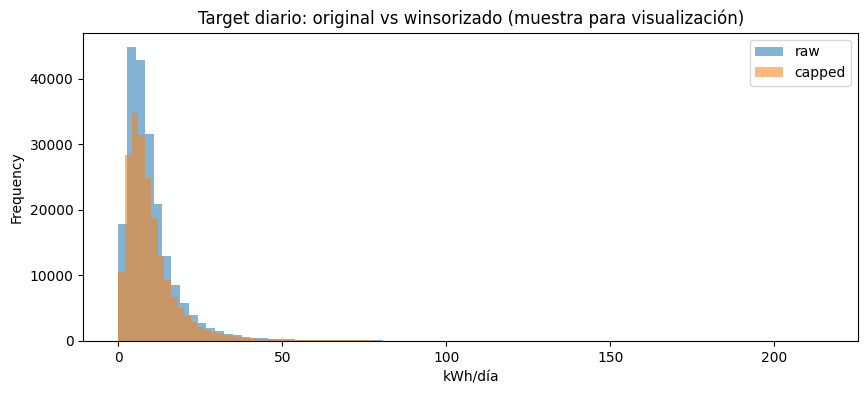

In [ ]:
audit_model = pd.read_csv(AUDIT_MODEL)
display(audit_model)

required = [
    'lag_1_kwh','lag_7_kwh','rolling_mean_7_kwh','rolling_std_7_kwh',
    'final_upper_cap','target_daily_kwh_raw','target_daily_kwh_capped'
]

split_stats = {}
nulls = {c: 0 for c in required}
total_model = 0
negative_targets = 0
above_cap = 0
sample_for_plot = []

for chunk in pd.read_csv(MODEL_CSV_GZ, chunksize=250_000):
    total_model += len(chunk)
    for split, n in chunk['dataset_split'].value_counts().items():
        split_stats[split] = split_stats.get(split, 0) + int(n)
    for c in required:
        nulls[c] += int(chunk[c].isna().sum())
    negative_targets += int((chunk['target_daily_kwh_capped'] < 0).sum())
    above_cap += int((chunk['target_daily_kwh_capped'] > chunk['final_upper_cap'] + 1e-12).sum())
    if len(sample_for_plot) < 5:
        sample_for_plot.append(chunk[['target_daily_kwh_raw','target_daily_kwh_capped']].sample(min(40_000, len(chunk)), random_state=42))

print('Filas finales:', f'{total_model:,}')
print('Split:', split_stats)
print('Nulos requeridos:', nulls)
print('Targets negativos:', negative_targets)
print('Targets sobre el cap:', above_cap)

assert total_model > 1_000_000
assert sum(nulls.values()) == 0
assert negative_targets == 0
assert above_cap == 0

plot_df = pd.concat(sample_for_plot, ignore_index=True)
ax = plot_df['target_daily_kwh_raw'].plot(kind='hist', bins=80, alpha=0.55, figsize=(10,4), label='raw')
plot_df['target_daily_kwh_capped'].plot(kind='hist', bins=80, alpha=0.55, ax=ax, label='capped')
ax.set_title('Target diario: original vs winsorizado (muestra para visualización)')
ax.set_xlabel('kWh/día')
ax.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE = Path("/content/drive/MyDrive/Grupo4_PCD_GO")

DAILY = BASE / "lcl_diario_go.csv"
MODEL = BASE / "lcl_modelo_go.csv.gz"
AUDIT = BASE / "audit_model_prep_go.csv"

print("Dataset diario:", DAILY)
print("¿Existe?:", DAILY.exists())

print("\nSalida del modelo:", MODEL)
print("Audit:", AUDIT)

if not DAILY.exists():
    raise FileNotFoundError(
        "No encuentro lcl_diario_go.csv. "
        "Verifica que esté dentro de MyDrive/Grupo4_PCD_GO/"
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset diario: /content/drive/MyDrive/Grupo4_PCD_GO/lcl_diario_go.csv
¿Existe?: True

Salida del modelo: /content/drive/MyDrive/Grupo4_PCD_GO/lcl_modelo_go.csv.gz
Audit: /content/drive/MyDrive/Grupo4_PCD_GO/audit_model_prep_go.csv


In [ ]:
import subprocess

cmd = [
    "/content/model_prep",
    "-in", str(DAILY),
    "-out", str(MODEL),
    "-audit", str(AUDIT),
]

print("Ejecutando:")
print(" ".join(cmd))
print()

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

for line in process.stdout:
    print(line, end="")

return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"model_prep terminó con código {return_code}"
    )

print("\n✅ Preparación del modelo completada.")
print("✅ Audit generado en:", AUDIT)
print("✅ Dataset de modelo generado en:", MODEL)

Ejecutando:
/content/model_prep -in /content/drive/MyDrive/Grupo4_PCD_GO/lcl_diario_go.csv -out /content/drive/MyDrive/Grupo4_PCD_GO/lcl_modelo_go.csv.gz -audit /content/drive/MyDrive/Grupo4_PCD_GO/audit_model_prep_go.csv

=== MODEL PREP GO ===
Hogares: 5560
Días completos usados: 3469352
Límite global 3xIQR (solo TRAIN): 35.257000 kWh
Filas finales del modelo: 3285438
Salida: /content/drive/MyDrive/Grupo4_PCD_GO/lcl_modelo_go.csv.gz
Auditoría: /content/drive/MyDrive/Grupo4_PCD_GO/audit_model_prep_go.csv

✅ Preparación del modelo completada.
✅ Audit generado en: /content/drive/MyDrive/Grupo4_PCD_GO/audit_model_prep_go.csv
✅ Dataset de modelo generado en: /content/drive/MyDrive/Grupo4_PCD_GO/lcl_modelo_go.csv.gz


In [ ]:
import pandas as pd

audit = pd.read_csv(AUDIT)

print("=" * 70)
print("AUDIT MODEL PREP GO")
print("=" * 70)

print(audit.to_string(index=False))

AUDIT MODEL PREP GO
   section              metric        value
    global    daily_input_rows 3.510403e+06
    global complete_daily_rows 3.469352e+06
    global          households 5.560000e+03
    global          model_rows 3.285438e+06
    global            train_q1 4.629000e+00
    global            train_q3 1.228600e+01
    global    global_upper_cap 3.525700e+01
     train                rows 2.559364e+06
     train         capped_rows 2.128000e+03
     train          capped_pct 8.310000e-02
     train            mean_raw 9.930660e+00
     train         mean_capped 9.917452e+00
     train             max_raw 3.325560e+02
     train          max_capped 2.392750e+02
validation                rows 4.521630e+05
validation         capped_rows 1.139000e+03
validation          capped_pct 2.519000e-01
validation            mean_raw 1.077968e+01
validation         mean_capped 1.074280e+01
validation             max_raw 2.708150e+02
validation          max_capped 1.739105e+02
      test  

In [ ]:
import pandas as pd

audit = pd.read_csv(AUDIT)

# Convertimos el audit a un diccionario cómodo:
# datos[seccion][metrica] = valor
datos = {}

for _, row in audit.iterrows():
    section = row["section"]
    metric = row["metric"]
    value = row["value"]

    datos.setdefault(section, {})
    datos[section][metric] = value


def numero(section, metric, default=0):
    try:
        return float(datos[section][metric])
    except:
        return default


def entero(section, metric):
    return int(round(numero(section, metric)))


print("=" * 75)
print("REPORTE FINAL DE PREPARACIÓN DEL DATASET PARA REGRESIÓN LINEAL")
print("=" * 75)

print("\n1. DATOS DE ENTRADA")
print("-" * 75)
print(f"Filas hogar-día recibidas: {entero('global', 'daily_input_rows'):,}")
print(f"Días completos aceptados:  {entero('global', 'complete_daily_rows'):,}")
print(f"Hogares considerados:       {entero('global', 'households'):,}")

input_rows = entero("global", "daily_input_rows")
complete_rows = entero("global", "complete_daily_rows")

if input_rows > 0:
    complete_pct = complete_rows / input_rows * 100
    print(f"Porcentaje de días completos: {complete_pct:.2f}%")


print("\n2. TRATAMIENTO DE OUTLIERS")
print("-" * 75)

q1 = numero("global", "train_q1")
q3 = numero("global", "train_q3")
cap = numero("global", "global_upper_cap")
iqr = q3 - q1

print(f"Q1 calculado únicamente con TRAIN: {q1:.4f} kWh")
print(f"Q3 calculado únicamente con TRAIN: {q3:.4f} kWh")
print(f"IQR:                              {iqr:.4f} kWh")
print(f"Límite global Q3 + 3×IQR:         {cap:.4f} kWh")


print("\n3. DATASET FINAL")
print("-" * 75)

model_rows = entero("global", "model_rows")
print(f"Filas finales disponibles para el modelo: {model_rows:,}")

if model_rows > 1_000_000:
    print("✅ Se mantiene un dataset superior a 1 millón de observaciones.")
else:
    print("⚠️ El dataset final quedó por debajo de 1 millón de observaciones.")


print("\n4. SPLIT TEMPORAL")
print("-" * 75)

for split in ["train", "validation", "test"]:

    if split not in datos:
        continue

    rows = entero(split, "rows")
    capped_rows = entero(split, "capped_rows")
    capped_pct = numero(split, "capped_pct")
    mean_raw = numero(split, "mean_raw")
    mean_capped = numero(split, "mean_capped")
    max_raw = numero(split, "max_raw")
    max_capped = numero(split, "max_capped")

    print(f"\n{split.upper()}")
    print(f"  Filas:                 {rows:,}")
    print(f"  Valores winsorizados:  {capped_rows:,}")
    print(f"  % winsorizado:          {capped_pct:.4f}%")
    print(f"  Media original:         {mean_raw:.4f} kWh")
    print(f"  Media winsorizada:      {mean_capped:.4f} kWh")
    print(f"  Máximo original:        {max_raw:.4f} kWh")
    print(f"  Máximo winsorizado:     {max_capped:.4f} kWh")


print("\n" + "=" * 75)
print("CONCLUSIÓN")
print("=" * 75)

print(
    f"""
El pipeline recibió {input_rows:,} observaciones hogar-día y conservó
{complete_rows:,} días completos. Después de construir las variables
temporales necesarias quedaron {model_rows:,} observaciones utilizables
por el modelo.

Los límites para tratar valores extremos fueron calculados exclusivamente
con TRAIN, evitando utilizar información de validation o test.

Los valores extremos no fueron eliminados: fueron winsorizados, y el
dataset conserva tanto el target original como el target tratado.

El conjunto se encuentra separado temporalmente en TRAIN, VALIDATION y
TEST y está preparado para la implementación de la Regresión Lineal.
"""
)

REPORTE FINAL DE PREPARACIÓN DEL DATASET PARA REGRESIÓN LINEAL

1. DATOS DE ENTRADA
---------------------------------------------------------------------------
Filas hogar-día recibidas: 3,510,403
Días completos aceptados:  3,469,352
Hogares considerados:       5,560
Porcentaje de días completos: 98.83%

2. TRATAMIENTO DE OUTLIERS
---------------------------------------------------------------------------
Q1 calculado únicamente con TRAIN: 4.6290 kWh
Q3 calculado únicamente con TRAIN: 12.2860 kWh
IQR:                              7.6570 kWh
Límite global Q3 + 3×IQR:         35.2570 kWh

3. DATASET FINAL
---------------------------------------------------------------------------
Filas finales disponibles para el modelo: 3,285,438
✅ Se mantiene un dataset superior a 1 millón de observaciones.

4. SPLIT TEMPORAL
---------------------------------------------------------------------------

TRAIN
  Filas:                 2,559,364
  Valores winsorizados:  2,128
  % winsorizado:          0.08


> El dataset Smart Meters in London se procesó directamente desde sus fragmentos CSV comprimidos mediante una implementación en Go basada exclusivamente en la biblioteca estándar. El procedimiento se diseñó como un pipeline de streaming para evitar cargar los aproximadamente 167 millones de registros originales en memoria. La primera etapa validó esquema, identificadores, tarifa, timestamps y consumo, descartó observaciones con errores de tipado, consumos negativos o marcas de tiempo fuera de la malla de 30 minutos, y resolvió duplicados por hogar y timestamp. Posteriormente, las lecturas válidas se agregaron a la unidad hogar-día. Debido a que los archivos originales están particionados, los agregados parciales se consolidaron mediante un k-way merge ordenado por hogar y fecha, evitando asumir que un hogar aparece en un único fragmento. Se conservaron como observaciones aptas para el modelo únicamente los días con 48 mediciones válidas y sin conflictos.
>
> La reducción del volumen no se realizó mediante un muestreo aleatorio de las filas crudas. Debido a que el objetivo es predecir consumo diario y las variables rezagadas requieren continuidad temporal, un muestreo de lecturas de media hora rompería las series y produciría días incompletos. En cambio, el cambio de granularidad de media hora a hogar-día reduce el dataset a aproximadamente 3.2–3.3 millones de observaciones sin eliminar arbitrariamente períodos completos. Los límites de valores extremos se estimaron únicamente sobre el conjunto de entrenamiento para evitar fuga de información, usando 3×IQR por hogar con un piso global calculado también sobre entrenamiento. Finalmente se construyeron variables temporales y rezagadas, conservando tanto el target original como el winsorizado para auditar el efecto del tratamiento.



## 8. Qué archivos deberían subir al repositorio

- `clean_daily.go` — limpieza estructural concurrente y agregación diaria.
- `model_prep.go` — winsorización sin leakage + features temporales.
- este notebook — evidencia reproducible de ejecución en Colab y EDA.
- `audit_cleaning_go.csv` y `audit_model_prep_go.csv` — evidencia cuantitativa para el informe.
